In [11]:
import torch

# 랜덤 요소를 고정하는 시드를 정합니다. 자유롭게 바꿔도 괜찮습니다.
seed = 2023

# Colab 환경의 T4 GPU를 사용하기 위해 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(seed=seed)
torch.set_float32_matmul_precision("high")

if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed=seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# FashionMNIST 데이터 셋을 가져옵니다.
# Colab 환경에 데이터 셋이 존재하지 않는다면 다운로드 받습니다.
# train 옵션을 통해 Train 데이터 셋과 Test 데이터 셋을 나누어 설정할 수 있습니다.
# transforms.ToTensor(): numpy.array 형태의 데이터를 torch.Tensor로 변경하고,
#                        0~1 사이의 값으로 스케일을 변경합니다.
train_dataset = datasets.FashionMNIST(
    root='./fashion_mnist/',
    train=True,
    transform=transforms.ToTensor(),
    download=True)

test_dataset = datasets.FashionMNIST(
    root='./fashion_mnist/',
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

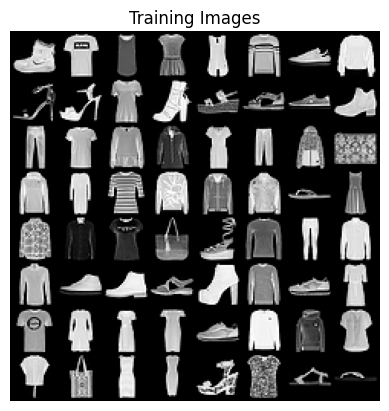

In [13]:
from torchvision import utils # 시각화를 위한 라이브러리
import matplotlib # 시각화를 위한 라이브러리
from matplotlib import pyplot as plt # 시각화를 위한 라이브러리
import numpy as np #numpy 데이터 형식을 다루기 위한 라이브러리

"""
64개 이미지 그려보기
1. train_dataset[idx][0]: 해당 idx의 이미지 (28x28 tensor)
2. torch.cat: 64개의 tensor를 합쳐 64x1x28x28 크기의 tensor로 만듦
3. torchvision.utils.make_grid: 1x296x296 크기의 np.ndarray로 바꿔줌 (normalize=True: 이미지를 [0,1] 범위로 바꿔줌)
4. plt.imshow 함수는 입력으로 WxHxC 순서의 데이터를 받으므로 296x296x1 크기로 transpose
"""
plt.axis('off')
plt.title("Training Images")
plt.imshow(np.transpose(utils.make_grid(torch.cat([train_dataset[i][0].unsqueeze(0) for i in range(64)], dim=0), normalize=True), (1,2,0)))

In [14]:
from torch import nn
import torch.nn.functional as F

In [34]:
"""
인코더
arguments:
    latent_dim: 잠재 벡터의 차원
"""
class Encoder(nn.Module):
    def __init__(self, latent_dim: int=2):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels= 1, out_channels =32, kernel_size=3, stride= 2)
        self.conv2 = nn.Conv2d(in_channels= 32, out_channels =64, kernel_size=3, stride= 2)
        self.fc_mean = nn.Linear(6*6*64, latent_dim)

    def forward(self, x: torch.Tensor):
        
        x = F.leaky_relu(self.conv1(x), negative_slope=0.2)
        x = F.leaky_relu(self.conv2(x), negative_slope=0.2)
        z = F.leaky_relu(self.fc_mean(x))
        return z

"""
디코더
arguments:
    latent_dim: 잠재 벡터의 차원
"""
class Decoder(nn.Module):
    def __init__(self, latent_dim: int=2):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 6*6*64)
        self.conv1 = nn.ConvTranspose2d(in_channels= 64, out_channels = 32, kernel_size=3, stride= 2)
        self.conv2 = nn.ConvTranspose2d(in_channels= 32, out_channels =1, kernel_size=3, stride= 2)

    def forward(self, z: torch.Tensor):
        z = F.leaky_relu(self.fc(z), negative_slope=0.2)
        z = F.leaky_relu(self.conv1(z), negative_slope=0.2)
        x_hat = F.sigmoid(self.conv2(z))

        return x_hat

In [27]:
train_dataset[0][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [30]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [33]:
train_dataset[0][1]

9

In [36]:
conv = nn.Conv2d(in_channels= 1, out_channels =32, kernel_size=3, stride= 2)

In [38]:
conv(train_dataset[0][0]).shape

torch.Size([32, 13, 13])

In [ ]:
Encoder(train_dataset[0][0])

In [16]:
"""
오토 인코더 모델
arguments:
    encoder: 오토 인코더의 인코더
    decoder: 오토 인코더의 디코더
    latent_dim: 잠재 벡터의 차원
"""

class Autoencoder(nn.Module):
    def __init__(self, encoder=Encoder, decoder=Decoder, latent_dim: int=2):

        # nn.Module의 __init__ 함수를 먼저 호출해줍니다
        super().__init__()
        # 인코더와 디코더 클래스를 설정합니다.
        self.encoder = encoder(latent_dim=latent_dim)
        self.decoder = decoder(latent_dim=latent_dim)

        self.latent_dim = latent_dim

    def forward(self, x: torch.Tensor):
        z = self.encode(x)
        x_hat = self.decode(z)
        return z, x_hat

    def encode(self, x: torch.Tensor):
        return self.encoder(x)

    def decode(self, z: torch.Tensor):
        return self.decoder(z)

In [17]:
class VariationalEncoder(Encoder):
    def __init__(self, latent_dim: int=2):
        super().__init__(latent_dim=latent_dim)

        self.fc_log_var = nn.Linear(7*7*64, latent_dim)

    def forward(self, x):
        
        x = F.leaky_relu(self.conv1(x), negative_slope=0.2)
        x = F.leaky_relu(self.conv2(x), negative_slope=0.2)

        mean = self.fc_mean(x)
        # 오토 인코더와의 주요 차이점
        log_var = self.fc_log_var(x)

        return mean, log_var

In [22]:
class VariationalAutoencoder(Autoencoder):
    def __init__(self, encoder=VariationalEncoder, decoder=Decoder, latent_dim: int=2):
        super().__init__(latent_dim=latent_dim)
        self.encoder = encoder(latent_dim)

    def reparameterize(self, mean: torch.Tensor, log_var: torch.Tensor):
        # 샘플링 시에도 기울기를 전달할 수 있도록 재매개변수화 합니다.
        std = torch.exp(0.5 * log_var)
        # randn_like 메소드는 입력된 인자와 같은 차원의 값들을
        # 표준 정규 분포에서 샘플링하여 반환합니다.
        epsilon = torch.randn_like(std)

        return mean + (epsilon * std)

    def forward(self, x: torch.Tensor):
        # 인코더를 통해 얻어지는 값이 오토 인코더와 다릅니다.
        mean, log_var = self.encode(x)
        # 재매개변수화를 진행합니다.
        z = self.reparameterize(mean, log_var)
        # 오토 인코더와 같습니다.
        x_hat = self.decode(z)

        return x_hat, mean, log_var

In [18]:
def KLDivergenceLoss(mean, log_var):
    return torch.sum(-0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp()))

In [19]:
def binary_cross_entropy(x, recon):
    return -torch.sum(x * torch.log(recon) + (1 - x) * torch.log(1 - recon))

In [20]:
# 학습률을 설정합니다. Adam 최적화기를 사용할 예정이므로, Adam의 기본값인 0.001을 사용합니다.
# 너무 크거나 작은 학습률이 아니라면, 자유롭게 변경 가능합니다.
learning_rate = 0.001

# Mini-batch Gradient Descent를 위한 배치 사이즈를 설정합니다.
batch_size = 100

# 학습할 에포크 수를 설정합니다.
# 너무 많거나 적은 횟수가 아니라면, 자유롭게 변경 가능합니다.
epochs = 30

# 오토 인코더의 잠재 변수 차원을 설정합니다.
# 차원을 줄이거나 늘리면서 변하는 결과물을 확인해보는 것도 많은 공부가 됩니다.
latent_dim = 2

# Dataloader를 정의합니다.
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False)

In [23]:
from torch import optim

vae = VariationalAutoencoder(latent_dim=latent_dim).to(device)

# 디코더의 손실 함수를 평균 제곱 오차를 활용할지, 이진 교차 엔트로피를 활용할지
# recon_loss = nn.MSELoss(reduction='sum')
recon_loss = binary_cross_entropy
kld_loss = KLDivergenceLoss
# KL-Divergence의 가중치를 설정합니다. 기본 값은 1입니다.
beta = 1

optimizer = optim.Adam(params=list(vae.parameters()), lr=learning_rate)

In [24]:
# 훈련 데이터 셋과 검증 데이터 셋에 대해 복원 손실과 KL-Divergence 손실을 기록합니다.
history = dict(
    train_recon=[],
    train_kld=[],
    valid_recon=[],
    valid_kld=[]
)

print(f"Training start with {epochs} epochs.")
for epoch in range(1, 1 + epochs):
    # 훈련 정보를 기록합니다.
    train_epoch_recon = 0
    train_epoch_kld = 0
    train_size = 0

    vae.train()
    for i, batch in enumerate(train_loader):
        image, label = batch
        image = image.to(device)
        train_size += label.size(0)


        # 변분 오토 인코더의 인코더가 평균과 분산을 반환합니다.
        latent_mean, latent_log_var = vae.encode(image)
        # 인코더가 반환한 평균과 분산으로 재매개변수화 트릭을 사용하여 잠재 변수를 얻습니다.
        latent = vae.reparameterize(latent_mean, latent_log_var)
        # 잠재 변수로부터 이미지를 복원합니다.
        reconstruction_image = vae.decode(latent)

        # 손실 함수를 계산하여 더해줍니다.
        train_recon = recon_loss(image, reconstruction_image)
        train_kld = kld_loss(latent_mean, latent_log_var)
        train_loss = train_recon + beta*train_kld

        train_epoch_recon += train_recon.item()
        train_epoch_kld += train_kld.item()

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

    test_epoch_recon = 0
    test_epoch_kld = 0
    test_size = 0

    vae.eval()
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            image, label = batch
            image = image.to(device)
            test_size += label.size(0)

            latent_mean, latent_log_var = vae.encode(image)
            latent = vae.reparameterize(latent_mean, latent_log_var)
            reconstruction_image = vae.decode(latent)

            test_recon = recon_loss(image, reconstruction_image)
            test_kld = kld_loss(latent_mean, latent_log_var)
            test_loss = test_recon + test_kld

            test_epoch_recon += test_recon.item()
            test_epoch_kld += test_kld.item()

    train_epoch_recon /= train_size
    train_epoch_kld /= train_size
    test_epoch_recon /= test_size
    test_epoch_kld /= test_size

    history["train_recon"].append(train_epoch_recon)
    history["train_kld"].append(train_epoch_kld)
    history["valid_recon"].append(test_epoch_recon)
    history["valid_kld"].append(test_epoch_kld)

    print(
        f"{epoch}th epoch: "
        + f"Train Recon Loss = {train_epoch_recon:.4f}, "
        + f"KLD loss = {train_epoch_kld:.4f}, "
        + f"Test Recon Loss = {test_epoch_recon:.4f}, "
        + f"KLD loss = {test_epoch_kld:.4f}"
    )

Training start with 30 epochs.


RuntimeError: mat1 and mat2 shapes cannot be multiplied (38400x6 and 3136x2)

In [ ]:
# 훈련 손실과 검증 손실에 대해 시각화합니다.
def visualize_loss(epochs, train_loss, valid_loss):
    x_len = np.arange(epochs)
    plt.plot(x_len, train_loss, marker=".", c="blue", label="Train Loss")
    plt.plot(x_len, valid_loss, marker=".", c="red", label="Valid Loss")
    plt.legend(loc='upper right')
    plt.grid()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()